
# Simple OLS Regression Example

This notebook generates a simple synthetic dataset on students' study hours and stress levels, fits an **OLS regression** using `statsmodels`, and produces basic residual plots.



## 1. Setup

In [1]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

sns.set(style="whitegrid")
np.random.seed(123)



## 2. Generate a simple dataset
We simulate a very common social‑science scenario:
- **StudyHours**: how many hours a student reports studying per week
- **Stress**: self‑rated stress (0–10)

We'll aid some noise to the dataset to check our regression finds the trend


In [2]:

N = 300
study = np.random.normal(12, 4, N).clip(0)
stress = 8 - 0.25*study + np.random.normal(0, 1.2, N)

# Put in DataFrame
df = pd.DataFrame({
    'StudyHours': study,
    'Stress': stress
})

df.head()


,StudyHours,Stress
0,7.657478,7.003696
1,15.989382,3.007868
2,13.131914,3.926040
3,5.974821,7.239643
4,9.685599,5.405784



## 3. Fit a simple OLS model
Model:
```
Stress = β₀ + β₁·StudyHours + ε
```


In [3]:

X = sm.add_constant(df['StudyHours'])
y = df['Stress']

model = sm.OLS(y, X).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Stress   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     280.0
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           8.84e-45
Time:                        22:35:20   Log-Likelihood:                -472.28
No. Observations:                 300   AIC:                             948.6
Df Residuals:                     298   BIC:                             956.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.3146      0.208     40.043      0.000       7.906       8.723
StudyHours    -0.2764      0.017    -16.735      0.000      -0.309      -0.244
==============================================================================
Omnibus:                        1.289   Durbin-Watson:                   1.940
Prob(Omnibus):                  0.525   Jarque-Bera (JB):                1.388
Skew:                          -0.132   Prob(JB):                        0.500
Kurtosis:                       2.796   Cond. No.                         38.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

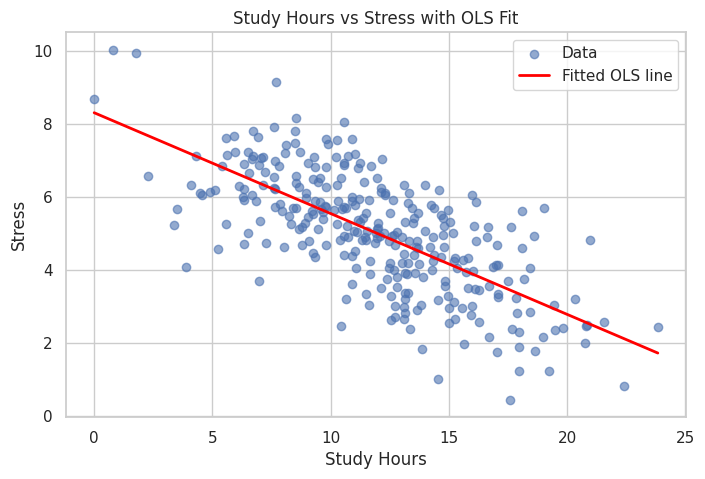

In [5]:
# Plot the fitted model on the data

plt.figure(figsize=(8,5))

# Scatter plot of the data
plt.scatter(df['StudyHours'], df['Stress'], alpha=0.6, label='Data')

# Create a smooth line of predicted values
x_vals = np.linspace(df['StudyHours'].min(), df['StudyHours'].max(), 200)
X_pred = sm.add_constant(x_vals)
y_pred = model.predict(X_pred)

# Plot fitted line
plt.plot(x_vals, y_pred, color='red', linewidth=2, label='Fitted OLS line')

plt.xlabel("Study Hours")
plt.ylabel("Stress")
plt.title("Study Hours vs Stress with OLS Fit")
plt.legend()
plt.show()



## 4. Residual diagnostics
We create:
- **Residuals vs fitted plot**
- **Histogram of residuals**
- **QQ plot**


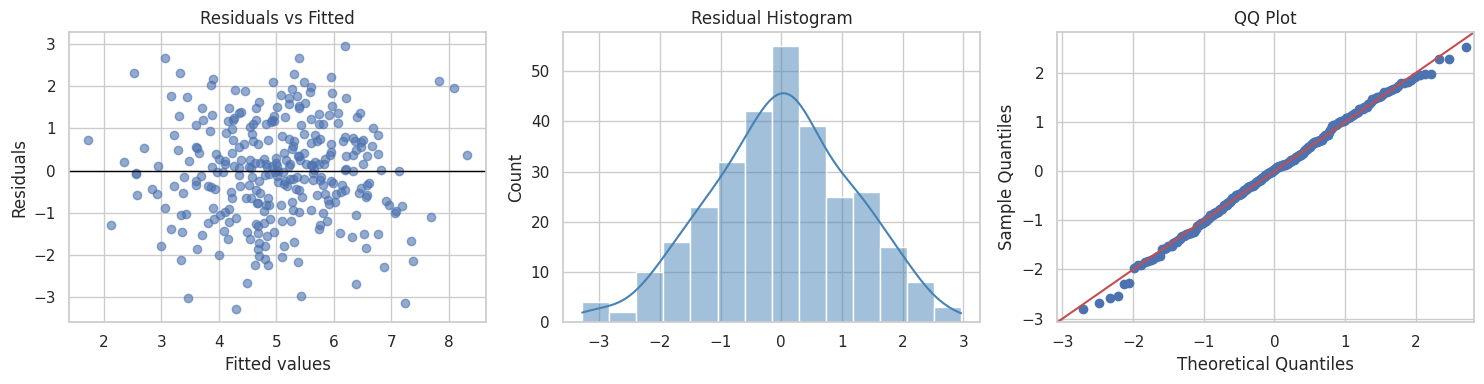

In [4]:

residuals = model.resid
fitted = model.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15,4))

# Residuals vs Fitted
axes[0].scatter(fitted, residuals, alpha=0.6)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# Histogram
sns.histplot(residuals, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Residual Histogram')

# QQ plot
sm.qqplot(residuals, line='45', fit=True, ax=axes[2])
axes[2].set_title('QQ Plot')

plt.tight_layout()
plt.show()



## 5. Interpretation
- The regression slope shows the estimated change in stress for each additional hour studied - comment on the relationship
- Residual plots help us check linearity and normality.


